# Waterpint status — classification code



## 1. Libraries


In [1]:

import numpy as np
import pandas as pd

## 2. Data loading


In [2]:
values_df = pd.read_csv("Water_Pump_Training_Set_Values.csv")
labels_df = pd.read_csv("Water_Pump_Training_Set_Labels.csv")
df = values_df.merge(labels_df, on="id", how="inner")
# Parse dates once; needed for year-based filters and age features later
df["date_recorded"] = pd.to_datetime(df["date_recorded"], errors="coerce")
df.shape


(59400, 41)

In [3]:
print(df.columns)


Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')


## 3. Exploratory Data Analysis (EDA)


/var/folders/gn/btjfhyhd541b_73l_jq76fw00000gn/T/ipykernel_735/812050932.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="status_group", order=order, palette="viridis")


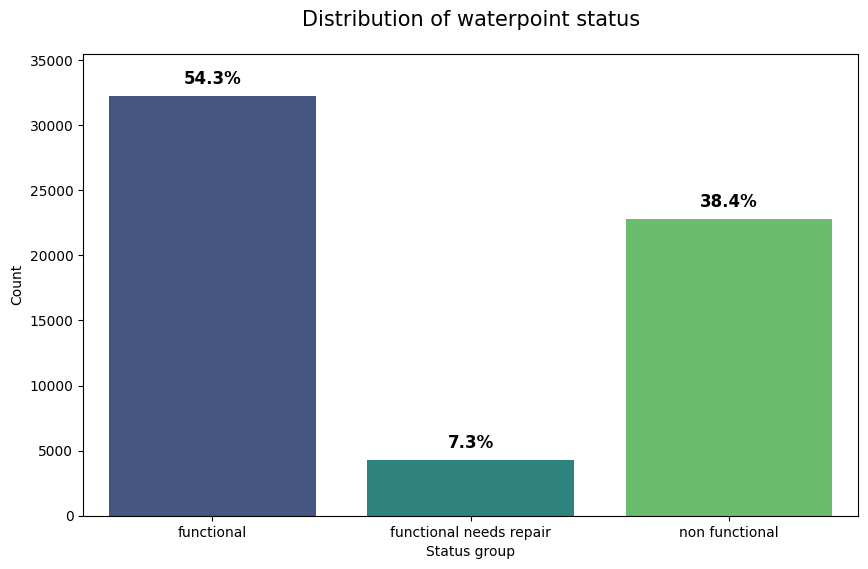

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
order = ["functional", "functional needs repair", "non functional"]
ax = sns.countplot(data=df, x="status_group", order=order, palette="viridis")

total = len(df["status_group"])
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(pct, (x, y), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title("Distribution of waterpoint status", fontsize=15, pad=20)
plt.xlabel("Status group")
plt.ylabel("Count")
plt.ylim(0, df["status_group"].value_counts().max() * 1.1)
plt.show()


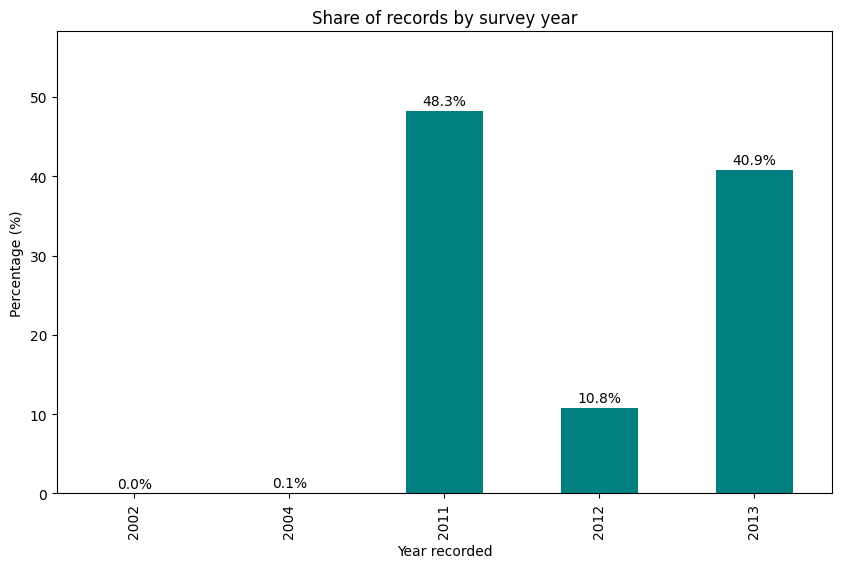

In [5]:
import matplotlib.pyplot as plt

year_stats = df["date_recorded"].dt.year.value_counts(normalize=True).sort_index() * 100
ax = year_stats.plot(kind="bar", color="teal", figsize=(10, 6))
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 7),
        textcoords="offset points",
    )
plt.title("Share of records by survey year")
plt.ylabel("Percentage (%)")
plt.xlabel("Year recorded")
plt.ylim(0, year_stats.max() + 10)
plt.show()


In [6]:
# Retain 2011–2013 where almost all observations lie
df = df[df["date_recorded"].dt.year.isin([2011, 2012, 2013])]


### Correlation structure (numeric features)


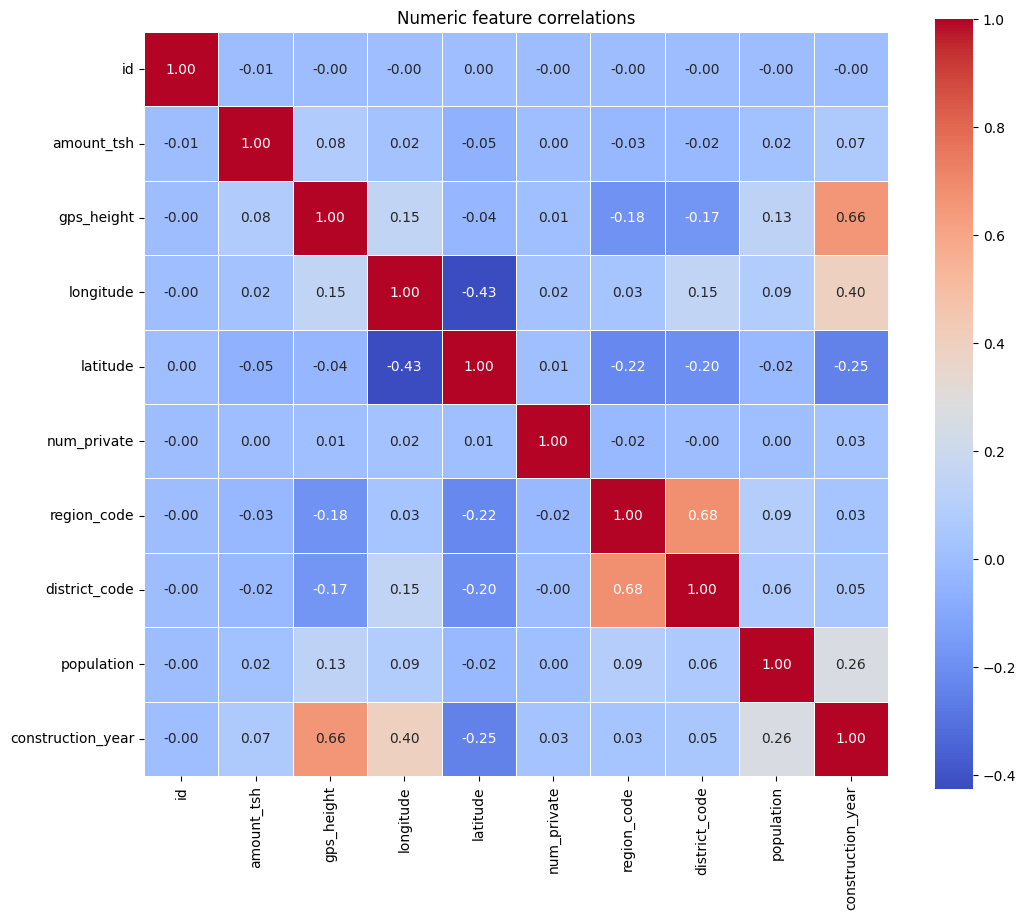

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
)
plt.title("Numeric feature correlations")
plt.show()


In [8]:
# Drop redundant / high-cardinality / leaky-style columns; keep grouped categoricals for modeling
cols_to_drop = [
    "funder",
    "installer",
    "wpt_name",
    "num_private",
    "subvillage",
    "region_code",
    "lga",
    "ward",
    "recorded_by",
    "scheme_management",
    "scheme_name",
    "extraction_type",
    "extraction_type_group",
    "management",
    "payment",
    "water_quality",
    "quantity",
    "source",
    "source_type",
    "waterpoint_type",
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(df.columns)


Index(['id', 'amount_tsh', 'date_recorded', 'gps_height', 'longitude',
       'latitude', 'basin', 'region', 'district_code', 'population',
       'public_meeting', 'permit', 'construction_year',
       'extraction_type_class', 'management_group', 'payment_type',
       'quality_group', 'quantity_group', 'source_class',
       'waterpoint_type_group', 'status_group'],
      dtype='str')


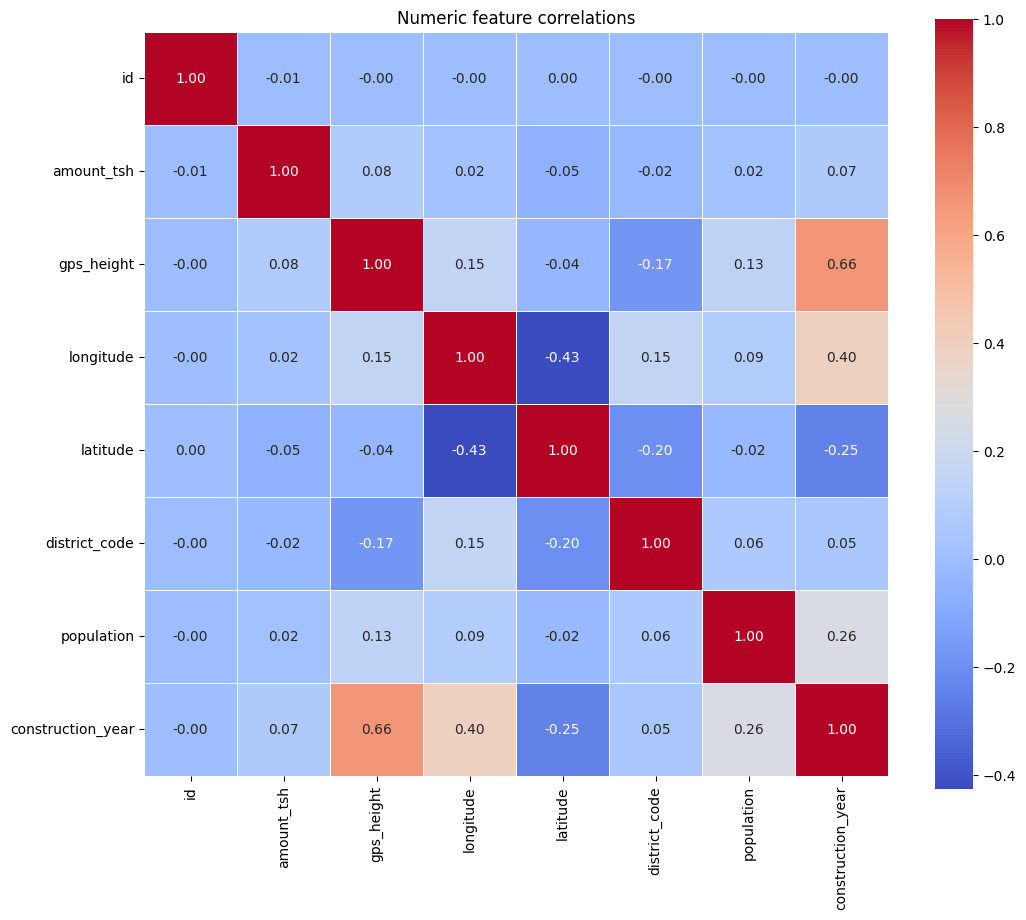

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
)
plt.title("Numeric feature correlations")
plt.show()

### Numeric summaries




In [10]:
def analyze_dataframe(df):
    stats = df.describe().transpose()
    stats["skew"] = df.skew(numeric_only=True)
    stats["kurtosis"] = df.kurt(numeric_only=True)
    stats["range"] = stats["max"] - stats["min"]
    stats["missing_values"] = df.isnull().sum()
    return stats


report = analyze_dataframe(df)
print(report)


                     count                        mean                  min  \
id                 59369.0                37118.642305                  0.0   
amount_tsh         59369.0                  317.804963                  0.0   
date_recorded        59369  2012-03-30 20:23:54.688136  2011-01-03 00:00:00   
gps_height         59369.0                   668.40319                -90.0   
longitude          59369.0                   34.076855                  0.0   
latitude           59369.0                   -5.706235            -11.64944   
district_code      59369.0                    5.627196                  0.0   
population         59369.0                  179.924135                  0.0   
construction_year  59369.0                 1300.759993                  0.0   

                                   25%                  50%  \
id                             18523.0              37064.0   
amount_tsh                         0.0                  0.0   
date_recorded      2

### EDA notes




## 4. Data cleaning


In [11]:
import numpy as np

# Invalid (0,0)-style coordinates and placeholder zeros → NaN for sensible imputation rules
df.loc[df["longitude"] == 0, "longitude"] = np.nan
df.loc[df["population"] == 0, "population"] = np.nan
df.loc[df["construction_year"] == 0, "construction_year"] = np.nan
df.loc[df["amount_tsh"] == 0, "construction_year"] = np.nan
df.loc[df["district_code"] == 0, "construction_year"] = np.nan


In [12]:
# Survey year (used with construction_year to build age)
df["record_year"] = df["date_recorded"].dt.year


In [13]:
counts = df.isnull().sum()
percent = (df.isnull().sum() / len(df)) * 100
missing_stats = pd.DataFrame({"Total Missing": counts, "Percentage (%)": percent})
missing_stats = missing_stats[missing_stats["Total Missing"] > 0].sort_values(
    by="Percentage (%)", ascending=False
)
print(missing_stats)


                   Total Missing  Percentage (%)
construction_year          42019       70.775994
population                 21369       35.993532
public_meeting              3328        5.605619
permit                      3055        5.145783
longitude                   1812        3.052098


In [14]:
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'gps_height', 'longitude',
       'latitude', 'basin', 'region', 'district_code', 'population',
       'public_meeting', 'permit', 'construction_year',
       'extraction_type_class', 'management_group', 'payment_type',
       'quality_group', 'quantity_group', 'source_class',
       'waterpoint_type_group', 'status_group', 'record_year'],
      dtype='str')


In [15]:
# Spatial imputation: district+region median, then region median
df["longitude"] = df["longitude"].fillna(
    df.groupby(["region", "district_code"])["longitude"].transform("median")
)
df["longitude"] = df["longitude"].fillna(df.groupby("region")["longitude"].transform("median"))


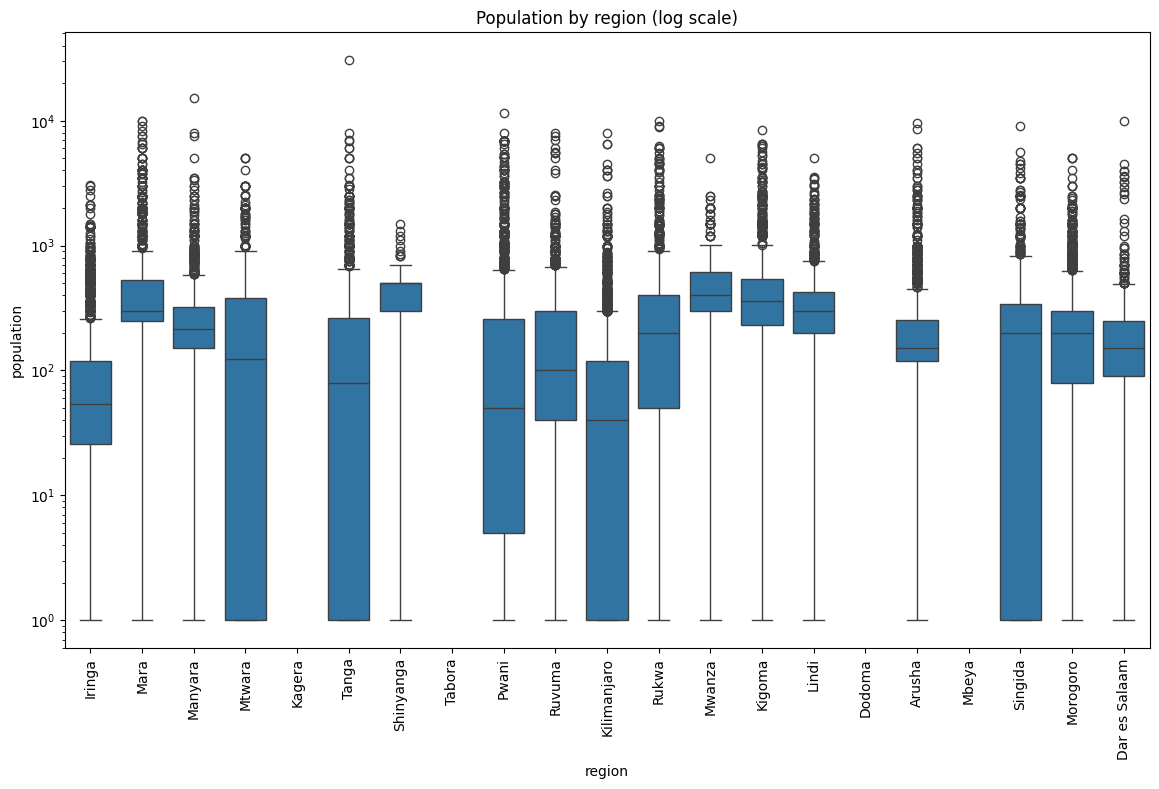

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x="region", y="population")
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Population by region (log scale)")
plt.show()


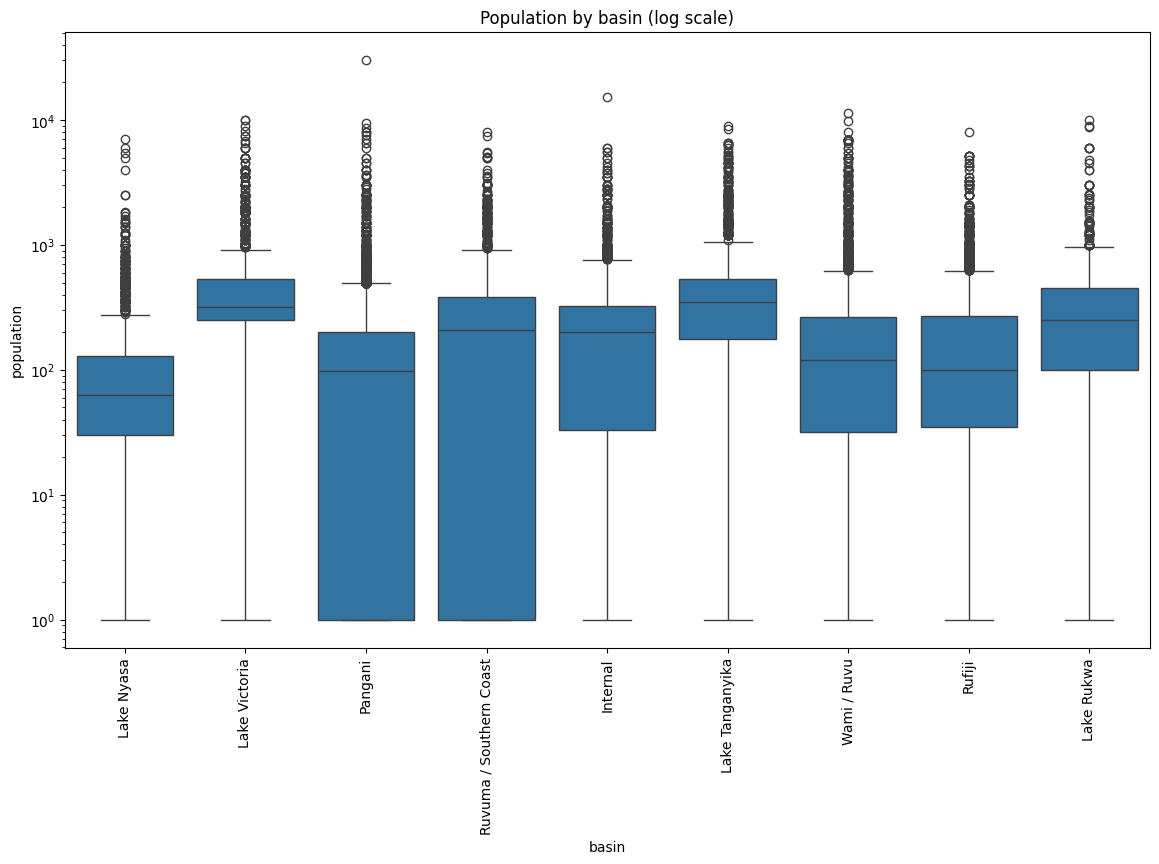

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x="basin", y="population")
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Population by basin (log scale)")
plt.show()


In [18]:
cols_to_check = ["population", "construction_year"]


def count_nulls(x):
    return x.isnull().sum()


missing_by_region = df.groupby("region")[cols_to_check].agg(count_nulls)
missing_by_region["total_rows_in_region"] = df.groupby("region").size()
missing_by_region["pop_missing_%"] = (
    missing_by_region["population"] / missing_by_region["total_rows_in_region"]
) * 100
print(missing_by_region.sort_values(by="pop_missing_%", ascending=False))


               population  construction_year  total_rows_in_region  \
region                                                               
Mbeya                4637               4637                  4637   
Dodoma               2201               2201                  2201   
Kagera               3312               3312                  3312   
Tabora               1959               1959                  1959   
Shinyanga            4814               4963                  4978   
Mwanza               2733               3055                  3097   
Iringa               1164               2086                  5293   
Ruvuma                467               1213                  2640   
Rukwa                  47               1141                  1807   
Kigoma                 31               1321                  2816   
Singida                 2               1266                  2093   
Pwani                   1               1252                  2632   
Arusha              

In [19]:
cols_to_check = ["population", "construction_year"]


def count_nulls(x):
    return x.isnull().sum()


missing_by_basin = df.groupby("basin")[cols_to_check].agg(count_nulls)
missing_by_basin["total_rows_in_basin"] = df.groupby("basin").size()
missing_by_basin["pop_missing_%"] = (
    missing_by_basin["population"] / missing_by_basin["total_rows_in_basin"]
) * 100
print(missing_by_basin.sort_values(by="pop_missing_%", ascending=False))


                         population  construction_year  total_rows_in_basin  \
basin                                                                         
Lake Victoria                  7710               9815                10237   
Lake Nyasa                     3184               3730                 5083   
Lake Rukwa                     1466               2066                 2454   
Lake Tanganyika                2864               4651                 6430   
Internal                       3108               6192                 7782   
Rufiji                         1765               4163                 7972   
Wami / Ruvu                    1015               3255                 5985   
Ruvuma / Southern Coast         256               2662                 4489   
Pangani                           1               5485                 8937   

                         pop_missing_%  
basin                                   
Lake Victoria                75.315034  
Lake Ny

In [20]:
# Hierarchical median imputation for population
df["population"] = df["population"].fillna(
    df.groupby("district_code")["population"].transform("median")
)
df["population"] = df["population"].fillna(
    df.groupby("region")["population"].transform("median")
)
df["population"] = df["population"].fillna(
    df.groupby("basin")["population"].transform("median")
)


### Construction year: explore and impute


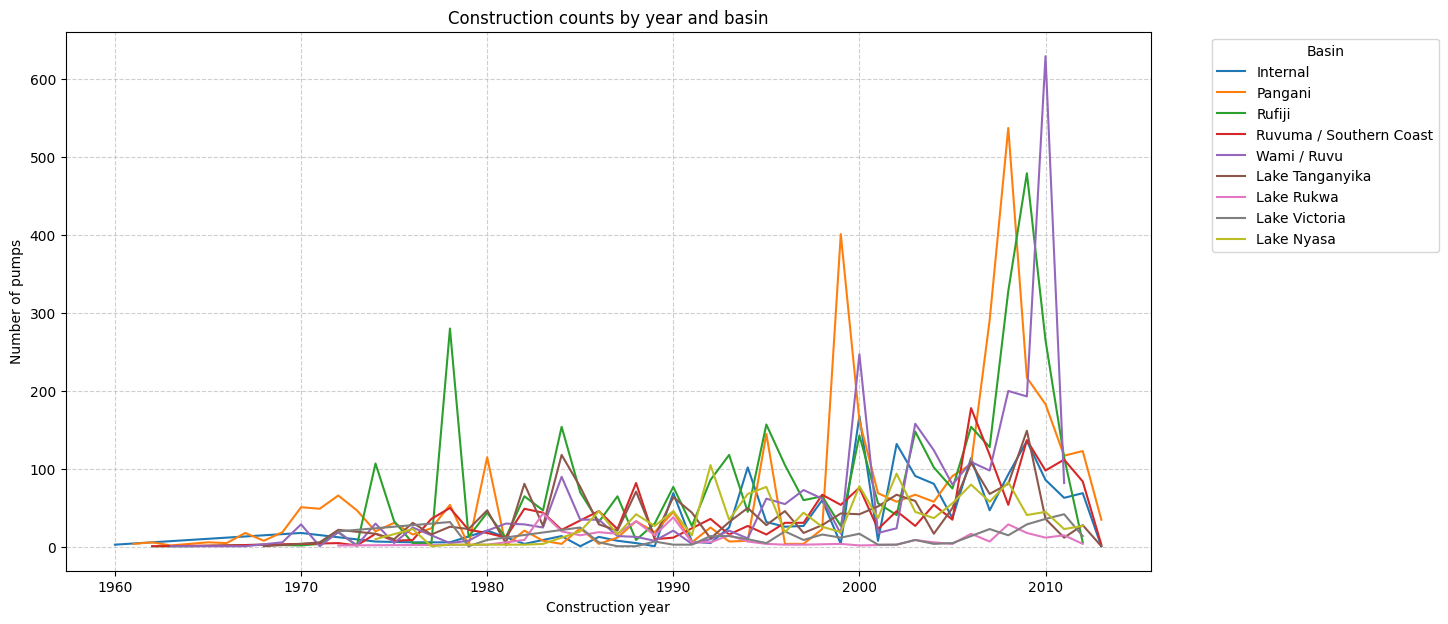

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df[df["construction_year"] > 0].copy()
frequency_data = (
    df_filtered.groupby(["construction_year", "basin"]).size().reset_index(name="count")
)
plt.figure(figsize=(14, 7))
sns.lineplot(data=frequency_data, x="construction_year", y="count", hue="basin")
plt.title("Construction counts by year and basin")
plt.xlabel("Construction year")
plt.ylabel("Number of pumps")
plt.legend(title="Basin", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("construction_age_by_basin.png", bbox_inches="tight")
plt.show()


In [22]:
df_valid = df[df["construction_year"] > 0]
counts = (
    df_valid.groupby(["basin", "construction_year"])
    .size()
    .reset_index(name="construction_count")
)
peak_years = counts.loc[counts.groupby("basin")["construction_count"].idxmax()]
peak_years = peak_years.sort_values(by="construction_count", ascending=False)
print(peak_years)


                       basin  construction_year  construction_count
361              Wami / Ruvu             2010.0                 629
224                  Pangani             2008.0                 537
272                   Rufiji             2009.0                 479
311  Ruvuma / Southern Coast             2006.0                 178
23                  Internal             2000.0                 168
141          Lake Tanganyika             2009.0                 149
50                Lake Nyasa             1992.0                 105
74                Lake Rukwa             1983.0                  43
176            Lake Victoria             2011.0                  42


In [23]:
# Fill missing construction_year with modal year per basin (excluding 0)
peak_year_series = (
    df[df["construction_year"] > 0]
    .groupby("basin")["construction_year"]
    .agg(lambda x: x.value_counts().idxmax())
)
mask = (df["construction_year"] == 0) | (df["construction_year"].isna())
df.loc[mask, "construction_year"] = df.loc[mask, "basin"].map(peak_year_series)


### Derived feature: `age_of_construction`


In [24]:
df["age_of_construction"] = np.where(
    df["construction_year"].isna(),
    np.nan,
    df["record_year"] - df["construction_year"],
)
df = df.drop(columns=["record_year", "date_recorded", "construction_year"])


In [25]:
print(df.isnull().sum())

id                          0
amount_tsh                  0
gps_height                  0
longitude                   0
latitude                    0
basin                       0
region                      0
district_code               0
population                  0
public_meeting           3328
permit                   3055
extraction_type_class       0
management_group            0
payment_type                0
quality_group               0
quantity_group              0
source_class                0
waterpoint_type_group       0
status_group                0
age_of_construction         0
dtype: int64


In [26]:
def _group_mode(series):
    """Most frequent non-null value in the group (same hierarchy idea as median for population)."""
    clean = series.dropna()
    if clean.empty:
        return np.nan
    m = clean.mode()
    return m.iloc[0] if len(m) else np.nan


# public_meeting & permit: district → region → basin (mode at each level)
for _col in ("public_meeting", "permit"):
    df[_col] = df[_col].fillna(
        df.groupby("district_code")[_col].transform(_group_mode)
    )
    df[_col] = df[_col].fillna(df.groupby("region")[_col].transform(_group_mode))
    df[_col] = df[_col].fillna(df.groupby("basin")[_col].transform(_group_mode))
    if df[_col].isna().any():
        _gm = df[_col].mode()
        df[_col] = df[_col].fillna(_gm.iloc[0] if len(_gm) else np.nan)

# district_code: missing code cannot join on district — use region → basin → global mode
if df["district_code"].isna().any():
    df["district_code"] = df["district_code"].fillna(
        df.groupby("region")["district_code"].transform(_group_mode)
    )
    df["district_code"] = df["district_code"].fillna(
        df.groupby("basin")["district_code"].transform(_group_mode)
    )
    if df["district_code"].isna().any():
        _dc_mode = df["district_code"].mode()
        df["district_code"] = df["district_code"].fillna(
            _dc_mode.iloc[0] if len(_dc_mode) else np.nan
        )


In [27]:
df.shape

(59369, 20)

In [28]:
print(df.columns)

Index(['id', 'amount_tsh', 'gps_height', 'longitude', 'latitude', 'basin',
       'region', 'district_code', 'population', 'public_meeting', 'permit',
       'extraction_type_class', 'management_group', 'payment_type',
       'quality_group', 'quantity_group', 'source_class',
       'waterpoint_type_group', 'status_group', 'age_of_construction'],
      dtype='str')


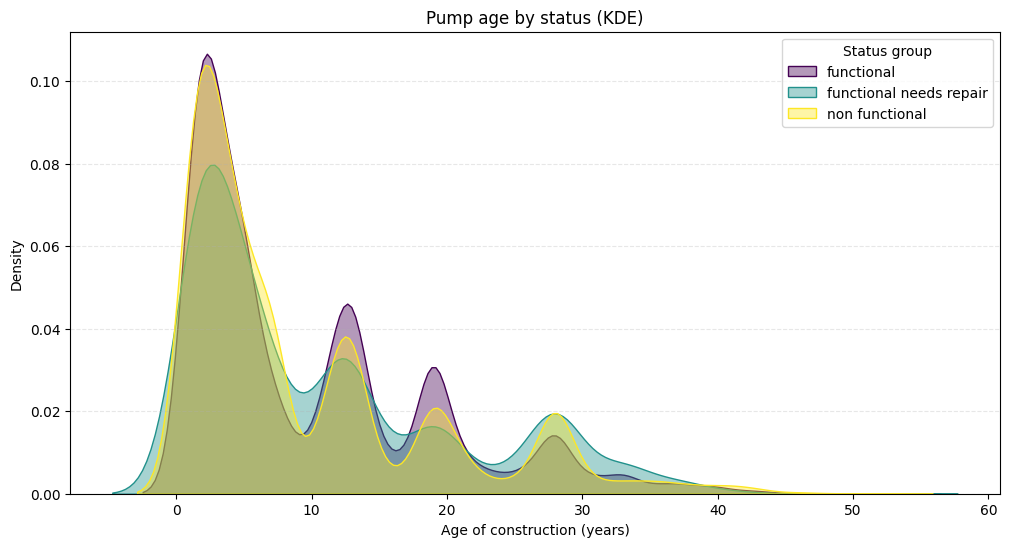

In [29]:
temp_df = df[["age_of_construction", "status_group"]].copy()
temp_df["age_of_construction"] = pd.to_numeric(temp_df["age_of_construction"], errors="coerce")
temp_df = temp_df[temp_df["age_of_construction"] > 0].dropna()

plt.figure(figsize=(12, 6))
colors = {
    "functional": "#440154",
    "functional needs repair": "#21918c",
    "non functional": "#fde725",
}
for status in ["functional", "functional needs repair", "non functional"]:
    subset = temp_df[temp_df["status_group"] == status]
    sns.kdeplot(
        subset["age_of_construction"],
        label=status,
        fill=True,
        color=colors.get(status, "gray"),
        alpha=0.4,
    )
plt.title("Pump age by status (KDE)")
plt.xlabel("Age of construction (years)")
plt.ylabel("Density")
plt.legend(title="Status group")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


## 5. Model building



In [30]:
df = df.drop(columns=["region", "district_code"], errors='ignore')

### Train / test split


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["id", "status_group"]).copy()

y = df["status_group"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True).sort_index())


Train rows: 47,495 | Test rows: 11,874

Train class proportions:
status_group
functional                 0.543173
functional needs repair    0.072702
non functional             0.384125
Name: proportion, dtype: float64


### Feature lists (categorical vs numeric)


In [32]:

categorical_cols = [
    "basin",
    "extraction_type_class",
    "management_group",
    "payment_type",
    "quality_group",
    "quantity_group",
    "source_class",
    "waterpoint_type_group",
    "public_meeting",
    "permit",
]
categorical_cols = [c for c in categorical_cols if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

**Note:** Cross-validation uses 5 stratified folds on the training set only; the test set is reserved for final metrics.


### Model: Logistic Regression

5-fold stratified CV , then test-set evaluation. **StandardScaler** on numeric columns only; **OneHotEncoder** on categoricals.


Cross-validation macro-F1: 0.5373 (+/- 0.0033)



Logistic Regression — test set
Accuracy: 0.6134
Macro-F1: 0.5403

Classification report:
                         precision    recall  f1-score   support

             functional       0.76      0.65      0.70      6450
functional needs repair       0.16      0.60      0.26       863
         non functional       0.80      0.56      0.66      4561

               accuracy                           0.61     11874
              macro avg       0.58      0.60      0.54     11874
           weighted avg       0.73      0.61      0.65     11874



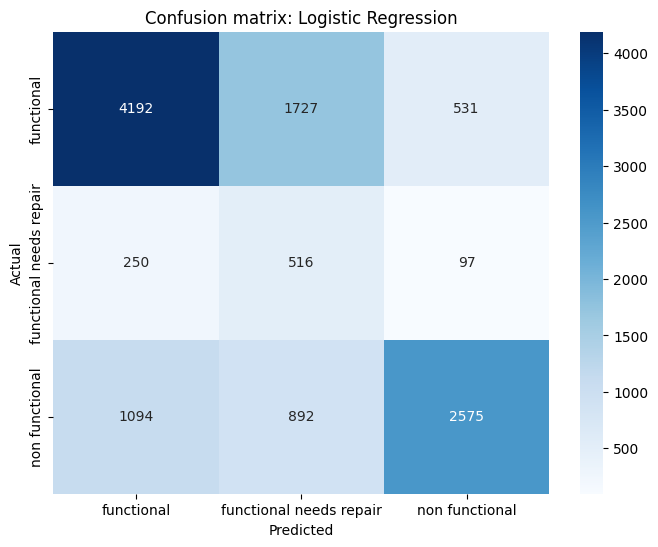

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

scaler = StandardScaler().fit(X_train[numeric_cols])
X_train_num = scaler.transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[categorical_cols])
X_train_cat = ohe.transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

model_lr = LogisticRegression(C=0.01, class_weight="balanced", max_iter=5000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_lr, X_train_final, y_train, cv=cv, scoring="f1_macro")
print(f"Cross-validation macro-F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

model_lr.fit(X_train_final, y_train)
y_pred = model_lr.predict(X_test_final)
y_pred_lr = y_pred

print("\n" + "=" * 30)
print("Logistic Regression — test set")
print("=" * 30)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model_lr.classes_,
    yticklabels=model_lr.classes_,
)
plt.title("Confusion matrix: Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


### Model: Random Forest

Same encodings as above but **no scaling**; class weights balanced.


Cross-validation macro-F1: 0.6837 (+/- 0.0064)



Random Forest — test set
Accuracy: 0.7828
Macro-F1: 0.6798
Weighted F1: 0.7854

Classification report (includes per-class precision / recall / F1):
                         precision    recall  f1-score   support

             functional       0.81      0.84      0.82      6450
functional needs repair       0.38      0.46      0.41       863
         non functional       0.84      0.76      0.80      4561

               accuracy                           0.78     11874
              macro avg       0.68      0.69      0.68     11874
           weighted avg       0.79      0.78      0.79     11874



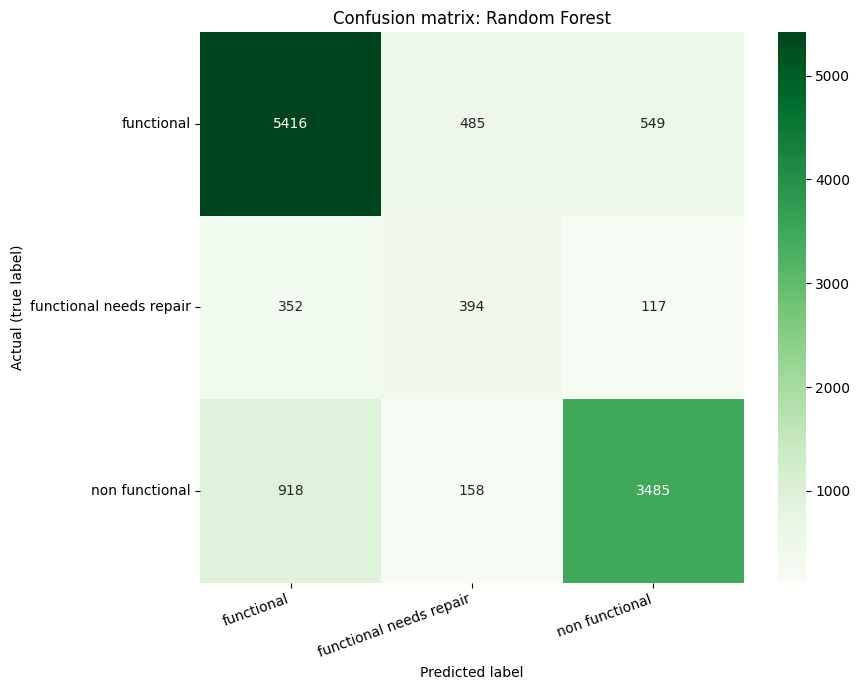

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[categorical_cols])
X_train_cat = ohe.transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])
X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_rf, X_train_final, y_train, cv=cv, scoring="f1_macro")
print(f"Cross-validation macro-F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

model_rf.fit(X_train_final, y_train)
y_pred = model_rf.predict(X_test_final)
y_pred_rf = y_pred

print("\n" + "=" * 30)
print("Random Forest — test set")
print("=" * 30)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification report (includes per-class precision / recall / F1):")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, labels=model_rf.classes_)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=model_rf.classes_,
    yticklabels=model_rf.classes_,
)
plt.title("Confusion matrix: Random Forest")
plt.ylabel("Actual (true label)")
plt.xlabel("Predicted label")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Model: XGBoost

Dense numeric + one-hot matrix (avoids native pandas categoricals for portability). Sample weights balance classes.


Running 5-fold CV for XGBoost...


Cross-validation macro-F1: 0.6142 (+/- 0.0020)



XGBoost — test set
Accuracy: 0.6931
Macro-F1 (equal weight per class): 0.6146
Weighted F1 (by support): 0.7198

Per-class F1 (test):
  'functional': 0.7575
  'functional needs repair': 0.3499
  'non functional': 0.7364

Full classification report:
                         precision    recall  f1-score   support

             functional       0.80      0.72      0.76      6450
functional needs repair       0.24      0.67      0.35       863
         non functional       0.83      0.66      0.74      4561

               accuracy                           0.69     11874
              macro avg       0.62      0.68      0.61     11874
           weighted avg       0.77      0.69      0.72     11874



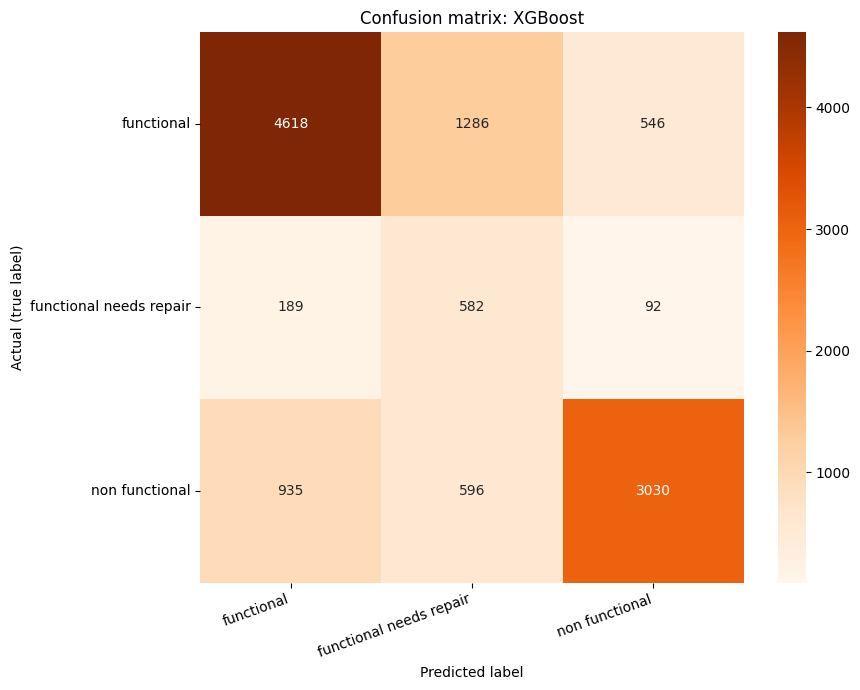

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

ohe_xgb = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[categorical_cols])
X_train_cat_xgb = ohe_xgb.transform(X_train[categorical_cols])
X_test_cat_xgb = ohe_xgb.transform(X_test[categorical_cols])
X_train_xgb_d = np.hstack([X_train[numeric_cols].values, X_train_cat_xgb])
X_test_xgb_d = np.hstack([X_test[numeric_cols].values, X_test_cat_xgb])

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method="hist",
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
print("Running 5-fold CV for XGBoost...")
for train_idx, val_idx in cv.split(X_train_xgb_d, y_train_enc):
    X_tr, X_va = X_train_xgb_d[train_idx], X_train_xgb_d[val_idx]
    y_tr, y_va = y_train_enc[train_idx], y_train_enc[val_idx]
    w = compute_sample_weight("balanced", y_tr)
    fold = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        tree_method="hist",
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
    )
    fold.fit(X_tr, y_tr, sample_weight=w)
    cv_scores.append(f1_score(y_va, fold.predict(X_va), average="macro"))

print(f"Cross-validation macro-F1: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

model_xgb.fit(X_train_xgb_d, y_train_enc, sample_weight=compute_sample_weight("balanced", y_train_enc))
y_pred_enc = model_xgb.predict(X_test_xgb_d)
y_pred_xgb = le.inverse_transform(y_pred_enc)

f1_macro = f1_score(y_test, y_pred_xgb, average="macro")
f1_weighted = f1_score(y_test, y_pred_xgb, average="weighted")

print("\n" + "=" * 30)
print("XGBoost — test set")
print("=" * 30)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Macro-F1 (equal weight per class): {f1_macro:.4f}")
print(f"Weighted F1 (by support): {f1_weighted:.4f}")
print("\nPer-class F1 (test):")
_f1_each = f1_score(y_test, y_pred_xgb, average=None, labels=le.classes_, zero_division=0)
for name, score in zip(le.classes_, _f1_each):
    print(f"  {name!r}: {score:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_xgb, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion matrix: XGBoost")
plt.ylabel("Actual (true label)")
plt.xlabel("Predicted label")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Binary classification (2-class problem) — improved

- **Classes:** `functional` vs **`non_functional_or_needs_repair`** (combines non-functional + needs repair).



=== XGBoost (binary) — 5-fold CV accuracy ===
0.8075 (+/- 0.0035)



[XGB binary] Validation accuracy at tuned threshold: 0.8077 (threshold P(non_functional_or_needs_repair) ≥ 0.570)



=== XGBoost (binary) — held-out test (tuned threshold) ===
Accuracy:    0.8114
Macro precision: 0.8142  |  Macro recall: 0.8057  |  Macro-F1: 0.8079

Classification report:
                                precision    recall  f1-score   support

                    functional       0.80      0.87      0.83      6450
non_functional_or_needs_repair       0.83      0.74      0.78      5424

                      accuracy                           0.81     11874
                     macro avg       0.81      0.81      0.81     11874
                  weighted avg       0.81      0.81      0.81     11874

Confusion matrix (rows=actual, cols=pred):
                                       pred:functional  \
actual:functional                                 5625   
actual:non_functional_or_needs_repair             1414   

                                       pred:non_functional_or_needs_repair  
actual:functional                                                      825  
actual:non_function

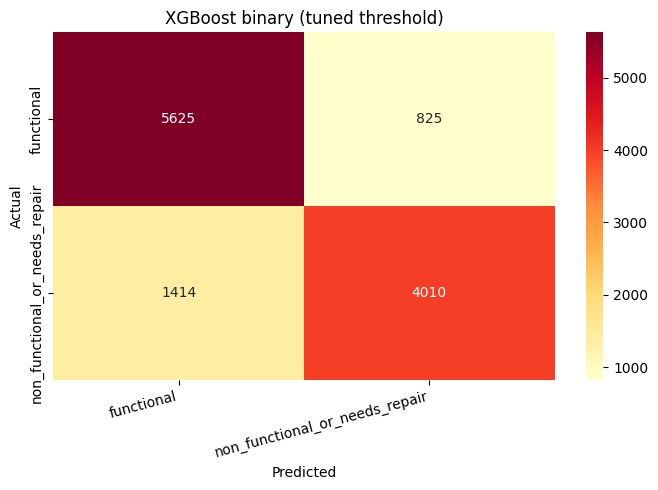


=== Random Forest (binary) — 5-fold CV accuracy ===
0.8135 (+/- 0.0040)



[RF binary] Validation accuracy at tuned threshold: 0.8083 (threshold P(non_functional_or_needs_repair) ≥ 0.510)



=== Random Forest (binary) — held-out test (tuned threshold) ===
Accuracy:    0.8168
Macro precision: 0.8182  |  Macro recall: 0.8121  |  Macro-F1: 0.8139

Classification report:
                                precision    recall  f1-score   support

                    functional       0.81      0.87      0.84      6450
non_functional_or_needs_repair       0.83      0.76      0.79      5424

                      accuracy                           0.82     11874
                     macro avg       0.82      0.81      0.81     11874
                  weighted avg       0.82      0.82      0.82     11874

Confusion matrix (rows=actual, cols=pred):
                                       pred:functional  \
actual:functional                                 5588   
actual:non_functional_or_needs_repair             1313   

                                       pred:non_functional_or_needs_repair  
actual:functional                                                      862  
actual:non_fu

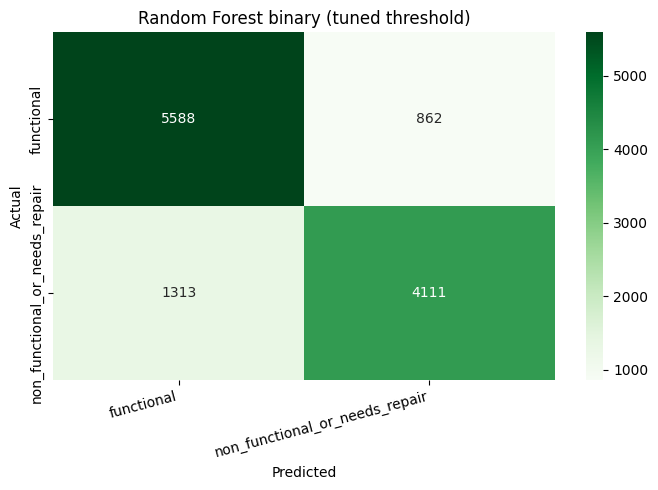

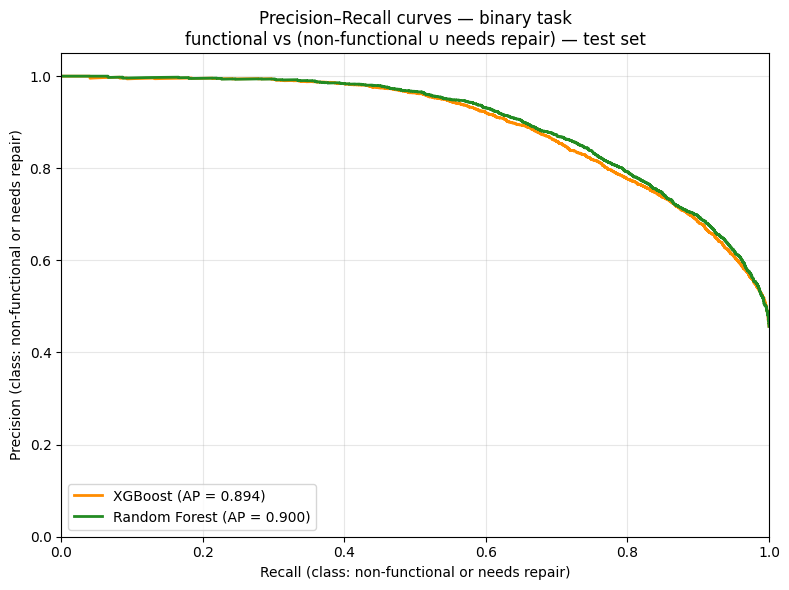


Average precision (failure class): XGBoost 0.8943 | Random Forest 0.8997


In [46]:
# Requires: multiclass XGBoost cell has already built X_train_xgb_d, X_test_xgb_d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

CLASS_OK = "functional"
CLASS_FAIL = "non_functional_or_needs_repair"


def collapse_binary(y):
    return y.map(lambda s: CLASS_OK if s == "functional" else CLASS_FAIL)


y_train_bin = collapse_binary(y_train)
y_test_bin = collapse_binary(y_test)

labels_bin = [CLASS_OK, CLASS_FAIL]

le_bin = LabelEncoder().fit(y_train_bin)
y_train_enc = le_bin.transform(y_train_bin)
y_test_enc = le_bin.transform(y_test_bin)

fail_idx = list(le_bin.classes_).index(CLASS_FAIL)

sw_bin = compute_sample_weight("balanced", y_train_enc)

# Imbalance ratio for XGBoost (neg = class 0 / pos = class 1 as encoded)
n0 = (y_train_enc == 0).sum()
n1 = (y_train_enc == 1).sum()
scale_pos_weight = float(n0 / max(n1, 1))

# Inner train / validation for probability-threshold tuning (improves accuracy vs default 0.5)
X_fit, X_thr, y_fit, y_thr = train_test_split(
    X_train_xgb_d,
    y_train_enc,
    test_size=0.18,
    random_state=42,
    stratify=y_train_enc,
)
sw_fit = compute_sample_weight("balanced", y_fit)


def tune_threshold(clf, X_val, y_val, proba_col_idx):
    """Pick threshold on P(failure) that maximizes accuracy on the validation fold."""
    proba = clf.predict_proba(X_val)[:, proba_col_idx]
    best_t, best_acc = 0.5, -1.0
    for t in np.linspace(0.08, 0.92, 85):
        pred = (proba >= t).astype(np.int32)
        acc = accuracy_score(y_val, pred)
        if acc > best_acc:
            best_acc = acc
            best_t = float(t)
    return best_t, best_acc


cv_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----- (1) XGBoost binary — stronger defaults + tuned threshold -----
xgb_bin = XGBClassifier(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.045,
    objective="binary:logistic",
    tree_method="hist",
    subsample=0.88,
    colsample_bytree=0.78,
    min_child_weight=2,
    gamma=0.08,
    reg_alpha=0.15,
    reg_lambda=2.2,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)

cv_scores_bin = cross_val_score(
    XGBClassifier(
        n_estimators=700,
        max_depth=8,
        learning_rate=0.045,
        objective="binary:logistic",
        tree_method="hist",
        subsample=0.88,
        colsample_bytree=0.78,
        min_child_weight=2,
        gamma=0.08,
        reg_alpha=0.15,
        reg_lambda=2.2,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    ),
    X_train_xgb_d,
    y_train_enc,
    cv=cv_bin,
    scoring="accuracy",
)
print("=== XGBoost (binary) — 5-fold CV accuracy ===")
print(f"{cv_scores_bin.mean():.4f} (+/- {cv_scores_bin.std():.4f})")

xgb_bin.fit(X_fit, y_fit, sample_weight=sw_fit)
thr_xgb, val_acc_xgb = tune_threshold(xgb_bin, X_thr, y_thr, fail_idx)
print(f"\n[XGB binary] Validation accuracy at tuned threshold: {val_acc_xgb:.4f} (threshold P({CLASS_FAIL}) ≥ {thr_xgb:.3f})")

xgb_bin.fit(X_train_xgb_d, y_train_enc, sample_weight=sw_bin)
proba_test_x = xgb_bin.predict_proba(X_test_xgb_d)[:, fail_idx]
y_pred_enc_x = (proba_test_x >= thr_xgb).astype(np.int32)
y_pred_xgb_bin = pd.Series(le_bin.inverse_transform(y_pred_enc_x), index=y_test.index)

acc_x = accuracy_score(y_test_bin, y_pred_xgb_bin)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_test_bin, y_pred_xgb_bin, average="macro", labels=labels_bin, zero_division=0
)

print("\n=== XGBoost (binary) — held-out test (tuned threshold) ===")
print(f"Accuracy:    {acc_x:.4f}")
print(f"Macro precision: {prec_m:.4f}  |  Macro recall: {rec_m:.4f}  |  Macro-F1: {f1_m:.4f}")
print("\nClassification report:")
print(classification_report(y_test_bin, y_pred_xgb_bin, labels=labels_bin, zero_division=0))

cm_x = confusion_matrix(y_test_bin, y_pred_xgb_bin, labels=labels_bin)
print("Confusion matrix (rows=actual, cols=pred):")
print(pd.DataFrame(cm_x, index=[f"actual:{x}" for x in labels_bin], columns=[f"pred:{x}" for x in labels_bin]))

plt.figure(figsize=(7, 5))
sns.heatmap(cm_x, annot=True, fmt="d", cmap="YlOrRd", xticklabels=labels_bin, yticklabels=labels_bin)
plt.title("XGBoost binary (tuned threshold)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# ----- (2) Random Forest binary — deeper ensemble + tuned threshold -----
rf_bin = RandomForestClassifier(
    n_estimators=600,
    max_depth=28,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

cv_rf_b = cross_val_score(
    RandomForestClassifier(
        n_estimators=600,
        max_depth=28,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    X_train_xgb_d,
    y_train_bin,
    cv=cv_bin,
    scoring="accuracy",
)
print("\n=== Random Forest (binary) — 5-fold CV accuracy ===")
print(f"{cv_rf_b.mean():.4f} (+/- {cv_rf_b.std():.4f})")

rf_bin.fit(X_fit, y_fit)
thr_rf, val_acc_rf = tune_threshold(rf_bin, X_thr, y_thr, fail_idx)
print(f"\n[RF binary] Validation accuracy at tuned threshold: {val_acc_rf:.4f} (threshold P({CLASS_FAIL}) ≥ {thr_rf:.3f})")

rf_bin.fit(X_train_xgb_d, y_train_bin)
proba_test_r = rf_bin.predict_proba(X_test_xgb_d)[:, fail_idx]
y_pred_rf_bin = pd.Series(
    np.where(proba_test_r >= thr_rf, CLASS_FAIL, CLASS_OK),
    index=y_test.index,
)

acc_r = accuracy_score(y_test_bin, y_pred_rf_bin)
prec_mr, rec_mr, f1_mr, _ = precision_recall_fscore_support(
    y_test_bin, y_pred_rf_bin, average="macro", labels=labels_bin, zero_division=0
)

print("\n=== Random Forest (binary) — held-out test (tuned threshold) ===")
print(f"Accuracy:    {acc_r:.4f}")
print(f"Macro precision: {prec_mr:.4f}  |  Macro recall: {rec_mr:.4f}  |  Macro-F1: {f1_mr:.4f}")
print("\nClassification report:")
print(classification_report(y_test_bin, y_pred_rf_bin, labels=labels_bin, zero_division=0))

cm_r = confusion_matrix(y_test_bin, y_pred_rf_bin, labels=labels_bin)
print("Confusion matrix (rows=actual, cols=pred):")
print(pd.DataFrame(cm_r, index=[f"actual:{x}" for x in labels_bin], columns=[f"pred:{x}" for x in labels_bin]))

plt.figure(figsize=(7, 5))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Greens", xticklabels=labels_bin, yticklabels=labels_bin)
plt.title("Random Forest binary (tuned threshold)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# ----- Precision–Recall curves (positive class = non-functional OR needs repair) -----
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binary ground truth: 1 = combined failure class, 0 = functional
y_true_fail = (y_test_bin == CLASS_FAIL).astype(np.int32)

ap_xgb = average_precision_score(y_true_fail, proba_test_x)
ap_rf = average_precision_score(y_true_fail, proba_test_r)

prec_x, rec_x, thresh_x = precision_recall_curve(y_true_fail, proba_test_x)
prec_r, rec_r, thresh_r = precision_recall_curve(y_true_fail, proba_test_r)

plt.figure(figsize=(8, 6))
plt.plot(rec_x, prec_x, lw=2, color="darkorange", label=f"XGBoost (AP = {ap_xgb:.3f})")
plt.plot(rec_r, prec_r, lw=2, color="forestgreen", label=f"Random Forest (AP = {ap_rf:.3f})")
plt.xlabel("Recall (class: non-functional or needs repair)")
plt.ylabel("Precision (class: non-functional or needs repair)")
plt.title(
    "Precision–Recall curves — binary task\n"
    "functional vs (non-functional ∪ needs repair) — test set"
)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.savefig("binary_functional_vs_failure_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAverage precision (failure class): XGBoost {:.4f} | Random Forest {:.4f}".format(ap_xgb, ap_rf))
